In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import csv
import torch
import numpy as np
from matplotlib import pyplot as plt
from collections import OrderedDict

import utils_data

In [2]:
def load_m4_file(filepath):
    series = OrderedDict()  # preserves order

    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        first = True
        for row in reader:
            if not row:
                continue
            if first:
                first = False
                continue
            series_id = row[0]
            values = [float(v) for v in row[1:] if v != '']
            series[series_id] = values

    return series

dataname = '../../data/baselines/Hourly-train.csv'
data     = load_m4_file(dataname)

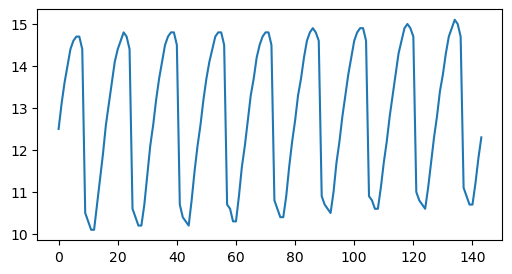

In [8]:
h = np.array(data['H223'])

plt.figure(figsize=(6,3))
plt.plot(h[16:160])
plt.show()

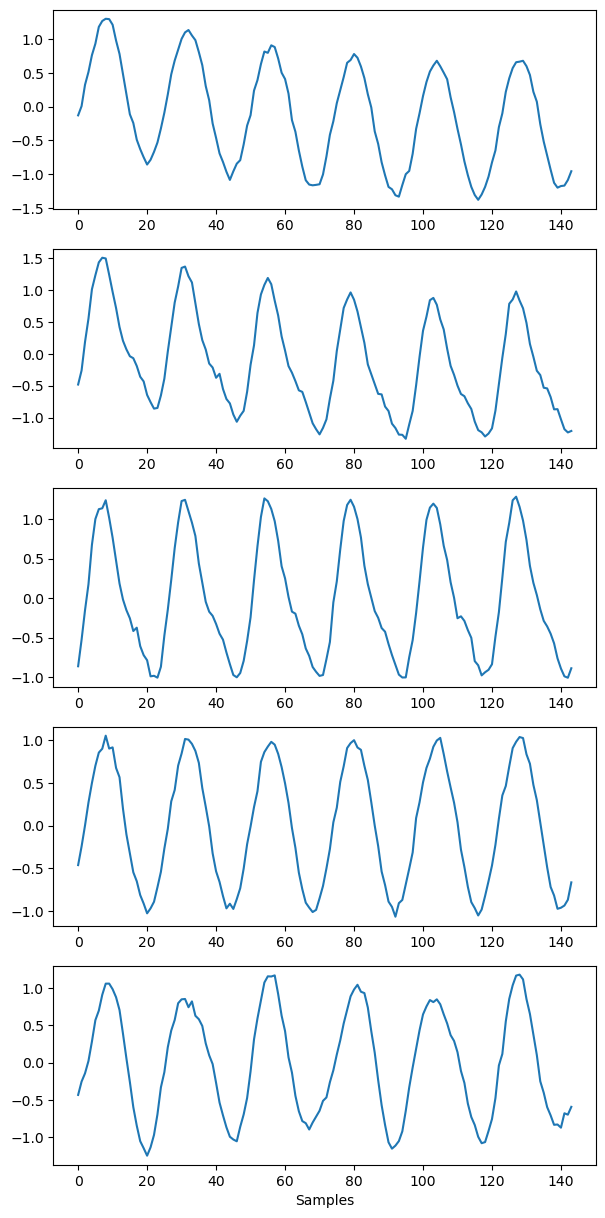

In [4]:
def sample_osc(t, f, a, a0, ns):
    u = np.stack([a0 * np.cos(2 * np.pi * f * t + a) for f, a, a0 in zip(f, a, a0)], axis=-1)
    u = np.sum(u, axis=-1, keepdims=True)
    u = u + np.random.normal(0, ns, size=u.shape)

    return u

t  = np.linspace(0, 52, 600)
ns = 0.04

sim_param = [
    # --! data combination 1 --!
    {
        'f'  : np.array([0.48, 0.048]),
        'a'  : np.array([0, 0]),
        'a0' : np.array([1.0, 0.35]),
    },
    # --! data combination 2 --!
    {
        'f'  : np.array([0.48, 0.96, 0.048]),
        'a'  : np.array([0, np.pi/3, 0]),
        'a0' : np.array([1.0, 0.3, 0.35]),
    },
    # --! data combination 3 --!
    {
        'f'  : np.array([0.48, 0.96]),
        'a'  : np.array([0, np.pi/3]),
        'a0' : np.array([1.0, 0.3]),
    },
    # --! data combination 4 --!
    {
        'f'  : np.array([0.48]),
        'a'  : np.array([0]),
        'a0' : np.array([1.0]),
    },
    # --! data combination 5 --!
    {
        'f'  : np.array([0.48, 0.8]),
        'a'  : np.array([0, np.pi/6]),
        'a0' : np.array([1.0, 0.2]),
    },
]

u = [sample_osc(t, p['f'], p['a'], p['a0'], ns) for p in sim_param]

# --! display simulation results --!

w  = 7
h  = 3
nu = len(u)

plt.figure(figsize=(w, nu*h))
for j, d in enumerate(u):
    plt.subplot(nu, 1, j + 1)
    plt.plot(d[16:160])
    if j==nu-1:
        plt.xlabel('Samples')
plt.show()

In [5]:
datasaved=True

if datasaved:
    savedata     = u
    savedir      = '../../data/baselines/m4_train_filter'
    data_nsample = 144
    utils_data.save_traindata(savedata, savedir, data_nsample)

inf >> training files saved
